# Практическая работа № 2
## 3D-графика в Matplotlib

**Студент:** Тоц Леонид Александрович, ИВТ-2
**Дата:** 16 сентября 2026

Этот ноутбук — заготовка для самостоятельного выполнения упражнений главы 3 «Выход в трёхмерный мир», включая упражнения, помеченные как мини-проекты. Точные формулировки взяты из PDF главы, а приёмы работы с Python и Matplotlib — из иллюстрированного пособия.

In [1]:
from math import acos, atan2, cos, degrees, isclose, pi, radians, sin, sqrt
import itertools
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

%matplotlib inline

In [2]:
def add(*vectors):
    return tuple(sum(coords) for coords in zip(*vectors))

def subtract(v1, v2):
    return tuple(a - b for a, b in zip(v1, v2))

def scale(scalar, v):
    return tuple(scalar * coord for coord in v)

def length(v):
    return sqrt(sum(coord ** 2 for coord in v))

def dot(u, v):
    return sum(a * b for a, b in zip(u, v))

def cross(u, v):
    ux, uy, uz = u
    vx, vy, vz = v
    return (uy * vz - uz * vy, uz * vx - ux * vz, ux * vy - uy * vx)

def unit(v):
    l = length(v)
    return scale(1.0 / l, v) if l != 0 else v

def angle_between(v1, v2):
    denom = length(v1) * length(v2)
    if denom == 0: return 0.0
    return acos(max(-1.0, min(1.0, dot(v1, v2) / denom)))

def set_equal_3d_axes(ax, points):
    pts = list(points) + [(0, 0, 0)]
    lows = [min(p[i] for p in pts) for i in range(3)]
    highs = [max(p[i] for p in pts) for i in range(3)]
    centers = [(l + h) / 2 for l, h in zip(lows, highs)]
    radius = max(max(h - l for l, h in zip(lows, highs)) / 2, 1.0) * 1.15
    ax.set(xlim=(centers[0] - radius, centers[0] + radius),
           ylim=(centers[1] - radius, centers[1] + radius),
           zlim=(centers[2] - radius, centers[2] + radius),
           xlabel="x", ylabel="y", zlabel="z")
    ax.set_box_aspect((1, 1, 1))

def box_edges(v):
    x, y, z = v
    return [
        ((0, y, 0), (x, y, 0)), ((0, 0, z), (0, y, z)), ((0, 0, z), (x, 0, z)),
        ((0, y, 0), (0, y, z)), ((x, 0, 0), (x, y, 0)), ((x, 0, 0), (x, 0, z)),
        ((0, y, z), (x, y, z)), ((x, 0, z), (x, y, z)), ((x, y, 0), (x, y, z))
    ]

### Упражнение 3.1
**Идея решения:** Вектор отображается как точка в координатах (-1, -2, 2) и стрелка из начала координат. Для передачи объема строится пунктирный параллелепипед, ребра которого параллельны осям.
**Проверка:** Конец стрелки визуально совпадает с нужной вершиной параллелепипеда, а остальные вершины проецируются на оси $x$, $y$ и $z$.

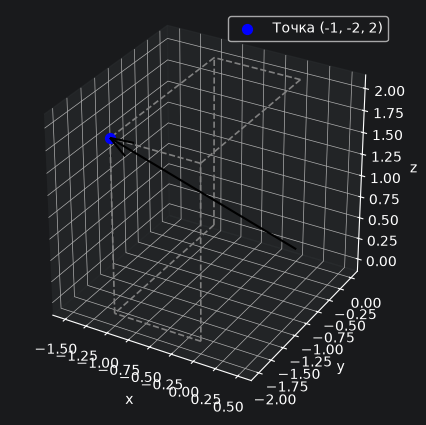

In [3]:
# Упражнение 3.1
target = (-1, -2, 2)
origin = (0, 0, 0)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(projection="3d")
ax.scatter(*target, color="blue", s=50, label="Точка (-1, -2, 2)")
ax.quiver(*origin, *target, color="black", arrow_length_ratio=0.1)

for start, end in box_edges(target):
    ax.plot(*zip(start, end), color="gray", linestyle="--", linewidth=1.2)

set_equal_3d_axes(ax, [target, origin])
ax.legend()
plt.show()

### Упражнение 3.2 — мини-проект
**Идея решения:** Восемь вершин генерируются декартовым произведением $\{-1, 1\}^3$. Две вершины образуют ребро, если они отличаются ровно по одной координате (по 4 ребра вдоль каждой из осей).
**Проверка:** Построено ровно 8 вершин и 12 рёбер. Длина каждого ребра равна 2.

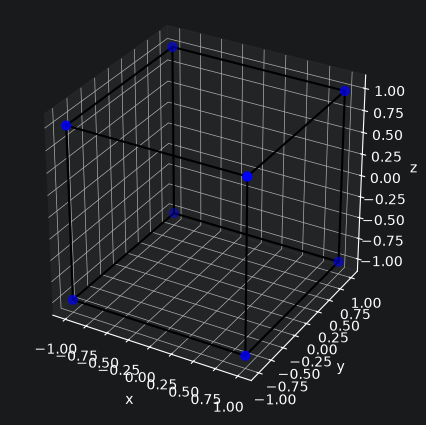

Вершин: 8, Ребер: 12


In [4]:
# Упражнение 3.2 — мини-проект
pm1 = [1, -1]
vertices = [(x, y, z) for x in pm1 for y in pm1 for z in pm1]
edges = [((-1, y, z), (1, y, z)) for y in pm1 for z in pm1] + \
        [((x, -1, z), (x, 1, z)) for x in pm1 for z in pm1] + \
        [((x, y, -1), (x, y, 1)) for x in pm1 for y in pm1]

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(projection="3d")
vx, vy, vz = zip(*vertices)
ax.scatter(vx, vy, vz, color="blue", s=40)

for start, end in edges:
    ax.plot(*zip(start, end), color="black", linewidth=1.5)

set_equal_3d_axes(ax, vertices)
plt.show()
print(f"Вершин: {len(vertices)}, Ребер: {len(edges)}")

### Упражнение 3.3
**Идея решения:** Сложение векторов $u$ и $v$ выполняется покоординатно. Визуально это правило параллелограмма: результат не зависит от порядка построения ломаной ($u \to v$ или $v \to u$).
**Проверка:** Аналитическая сумма $(4 - 1, 0 + 0, 3 + 1) = (3, 0, 4)$. Обе цепочки приходят в одну точку.

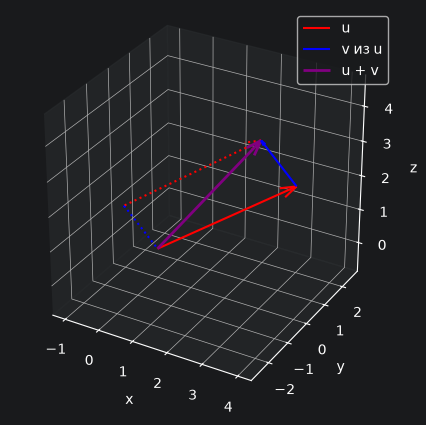

Сумма u+v = (3, 0, 4)


In [5]:
# Упражнение 3.3
u, v = (4, 0, 3), (-1, 0, 1)
w = add(u, v)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(projection="3d")
ax.quiver(0, 0, 0, *u, color="red", arrow_length_ratio=0.1, label="u")
ax.quiver(*u, *v, color="blue", arrow_length_ratio=0.1, label="v из u")
ax.quiver(0, 0, 0, *v, color="blue", arrow_length_ratio=0.1, linestyle=":")
ax.quiver(*v, *u, color="red", arrow_length_ratio=0.1, linestyle=":")
ax.quiver(0, 0, 0, *w, color="purple", arrow_length_ratio=0.1, linewidth=2, label="u + v")

set_equal_3d_axes(ax, [(0, 0, 0), u, v, w])
ax.legend()
plt.show()
print(f"Сумма u+v = {w}")

### Упражнение 3.4
**Идея решения:** Функция `zip(*vectors)` транспонирует список координат, объединяя компоненты с одинаковыми индексами.
**Проверка:** Длина полученного списка совпадает с размерностью векторов (5 для первой группы и 2 для второй).

In [6]:
# Упражнение 3.4
vectors1 = [(1, 2, 3, 4, 5), (6, 7, 8, 9, 10)]
vectors2 = [(1, 2), (3, 4), (5, 6)]

len1 = len(list(zip(*vectors1)))
len2 = len(list(zip(*vectors2)))

print(f"Длина zip(*vectors1): {len1} (5 измерений)")
print(f"Длина zip(*vectors2): {len2} (2 измерения)")

Длина zip(*vectors1): 5 (5 измерений)
Длина zip(*vectors2): 2 (2 измерения)


### Упражнение 3.5 — мини-проект
**Идея решения:** Цепочка из 24 векторов формирует винтовую спираль. Координаты $x$ и $y$ образуют полные периоды синусоиды и косинусоиды, обнуляясь, а $z$-компоненты складываются: 24 шага по 1/3.
**Проверка:** Итоговая сумма должна быть (0, 0, 8). Из-за погрешности вычислений с плавающей точкой значения $x$ и $y$ исчезающе малы (около $10^{-16}$).

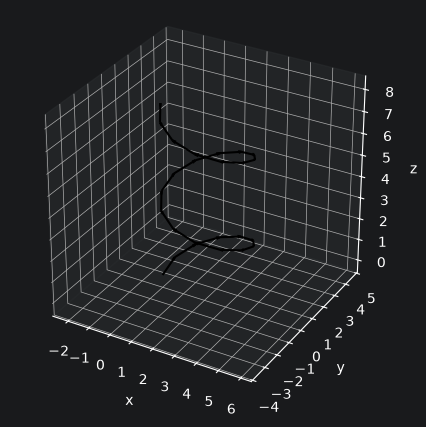

Округленная сумма: (-0.0, -0.0, 8.0)


In [7]:
# Упражнение 3.5 — мини-проект
vs = [(sin(pi * t / 6), cos(pi * t / 6), 1.0 / 3) for t in range(0, 24)]
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(projection="3d")

running_sum = (0.0, 0.0, 0.0)
trajectory = [running_sum]

for v in vs:
    next_sum = add(running_sum, v)
    step = subtract(next_sum, running_sum)
    ax.quiver(*running_sum, *step, color="black", arrow_length_ratio=0.15)
    running_sum = next_sum
    trajectory.append(running_sum)

set_equal_3d_axes(ax, trajectory)
plt.show()

rounded_sum = tuple(round(c, 6) for c in running_sum)
print(f"Округленная сумма: {rounded_sum}")

### Упражнение 3.6
**Идея решения:** Масштабирование вектора произвольной размерности — это независимое умножение каждой его координаты на заданный скаляр через генератор.
**Проверка:** $3 \cdot (1, 2) = (3, 6)$, а $2 \cdot (1, 2, 3) = (2, 4, 6)$.

In [8]:
# Упражнение 3.6
print("scale(3, (1, 2)) =", scale(3, (1, 2)))
print("scale(2, (1, 2, 3)) =", scale(2, (1, 2, 3)))
print("scale(-0.5, (4, -8, 2, 0)) =", scale(-0.5, (4, -8, 2, 0)))

scale(3, (1, 2)) = (3, 6)
scale(2, (1, 2, 3)) = (2, 4, 6)
scale(-0.5, (4, -8, 2, 0)) = (-2.0, 4.0, -1.0, -0.0)


### Упражнение 3.7
**Идея решения:** Алгебраическое выражение $u + \frac{1}{2}(v - u)$ равносильно $\frac{1}{2}(u + v)$ и геометрически задает середину отрезка между точками $u$ и $v$.
**Проверка:** Ожидаемый результат: $(1 + 0.5(0 - 1), -1 + 0.5(0 - (-1)), -1 + 0.5(2 - (-1))) = (0.5, -0.5, 0.5)$.

In [9]:
# Упражнение 3.7
u, v = (1, -1, -1), (0, 0, 2)

diff = subtract(v, u)
result = add(u, scale(0.5, diff))
midpoint = scale(0.5, add(u, v))

print(f"Результат: {result}")
print(f"Середина: {midpoint}")

Результат: (0.5, -0.5, 0.5)
Середина: (0.5, -0.5, 0.5)


### Упражнение 3.8
**Идея решения:** Длина вектора в пространстве любой размерности вычисляется как квадратный корень из суммы квадратов его компонент.
**Проверка:** $\|(1,1)\| = \sqrt{2}$, $\|(1,1,1)\| = \sqrt{3}$, $\|(1,1,1,1)\| = \sqrt{4} = 2$.

In [10]:
# Упражнение 3.8
for v in [(1, 1), (1, 1, 1), (1, 1, 1, 1)]:
    print(f"Длина вектора {v} = {length(v):.4f}")

Длина вектора (1, 1) = 1.4142
Длина вектора (1, 1, 1) = 1.7321
Длина вектора (1, 1, 1, 1) = 2.0000


### Упражнение 3.9 — мини-проект
**Идея решения:** Поиск троек целых чисел (аналог пифагоровых троек, но для 3D), где сумма их квадратов является полным квадратом. Используется перебор координат циклом.
**Проверка:** Вектор (2, 2, 1) дает длину $\sqrt{4+4+1} = 3$.

In [11]:
# Упражнение 3.9 — мини-проект
def find_integer_lengths(limit=15):
    res = []
    for x in range(1, limit):
        for y in range(x, limit):
            for z in range(y, limit):
                l = length((x, y, z))
                if l.is_integer():
                    res.append(((x, y, z), int(l)))
    return res

for vec, l in find_integer_lengths()[:3]:
    print(f"Вектор {vec} имеет целую длину {l}")

Вектор (1, 2, 2) имеет целую длину 3
Вектор (1, 4, 8) имеет целую длину 9
Вектор (1, 12, 12) имеет целую длину 17


### Упражнение 3.10
**Идея решения:** Нормировка вектора осуществляется умножением на скаляр, равный обратной величине его длины ($s = 1/\|v\|$).
**Проверка:** Длина итогового вектора должна быть строго равна 1.

In [12]:
# Упражнение 3.10
v = (-1, -1, 2)
unit_v = unit(v)

print(f"Вектор: {v} (длина {length(v):.4f})")
print(f"Единичный вектор: {unit_v}")
print(f"Проверочная длина: {length(unit_v)}")

Вектор: (-1, -1, 2) (длина 2.4495)
Единичный вектор: (-0.4082482904638631, -0.4082482904638631, 0.8164965809277261)
Проверочная длина: 1.0


### Упражнение 3.11
**Идея решения:** Знак скалярного произведения зависит от косинуса угла. Острый угол дает положительный результат, тупой — отрицательный.
**Проверка:** Из чертежа в книге: $u$ и $v$ сонаправлены (+), $v$ и $w$ образуют тупой угол (-), $u$ и $w$ образуют еще больший тупой угол, умноженный на большую длину вектора $u$ (-). Порядок убывания: $u \cdot v > v \cdot w > u \cdot w$.

In [13]:
# Упражнение 3.11
print("Порядок убывания: u·v > v·w > u·w")

Порядок убывания: u·v > v·w > u·w


### Упражнение 3.12
**Идея решения:** Вычисляем сумму покоординатных произведений. Если $u \cdot v < 0$, то $\cos\theta < 0$, следовательно, угол тупой (строго больше 90°).
**Проверка:** $-1 \cdot 1 - 1 \cdot 2 + 1 \cdot 1 = -2$. Угол тупой.

In [14]:
# Упражнение 3.12
u, v = (-1, -1, 1), (1, 2, 1)
dp = dot(u, v)
ang = degrees(angle_between(u, v))

print(f"Скалярное произведение: {dp}")
print(f"Угол: {ang:.2f}° (> 90°)")

Скалярное произведение: -2
Угол: 118.13° (> 90°)


### Упражнение 3.13 — мини-проект
**Идея решения:** Скалярное произведение обладает свойством линейности: $(su) \cdot v = \sum (su_i)v_i = s \sum u_i v_i = s(u \cdot v)$. Масштабирование одного из векторов масштабирует и итоговое произведение.
**Проверка:** Численная проверка тождества на заданных векторах.

In [15]:
# Упражнение 3.13 — мини-проект
s = 2.75
u, v = (2, -1, 3), (-4, 5, 2)

res1 = dot(scale(s, u), v)
res2 = dot(u, scale(s, v))
res3 = s * dot(u, v)

print(f"(su)·v = {res1}, u·(sv) = {res2}, s(u·v) = {res3}")
assert isclose(res1, res3) and isclose(res2, res3)

(su)·v = -19.25, u·(sv) = -19.25, s(u·v) = -19.25


### Упражнение 3.14 — мини-проект
**Идея решения:** Скалярное произведение вектора на самого себя: $v \cdot v = x^2 + y^2 + z^2$. Это совпадает с подкоренным выражением теоремы Пифагора для длины вектора.
**Проверка:** Равенство $v \cdot v = \|v\|^2$ должно выполняться для любого вектора.

In [16]:
# Упражнение 3.14 — мини-проект
v = (3, -4, 12)
dot_vv = dot(v, v)
len_sq = length(v)**2
print(f"v·v = {dot_vv}, |v|^2 = {len_sq}")

v·v = 169, |v|^2 = 169.0


### Упражнение 3.15 — мини-проект
**Идея решения:** По неравенству Коши — Буняковского скалярное произведение ограничено диапазоном $[- |u||v|, |u||v|]$. Для длин 3 и 7 границы равны $[-21, 21]$. Сонаправленные векторы дадут 21, противоположно направленные -21.
**Проверка:** Использование тригонометрических углов (60°, 90°, 120°) генерирует векторы, чьи скалярные произведения равны 10.5, 0 и -10.5, что строго укладывается в диапазон.

In [17]:
# Упражнение 3.15 — мини-проект
pairs = [
    ((3, 0), (7, 0)),             # Сонаправлены -> 21
    ((3, 0), (-7, 0)),            # Противонаправлены -> -21
    ((3, 0), (7*cos(pi/3), 7*sin(pi/3))),  # Угол 60° -> 10.5
    ((3, 0), (0, 7)),             # Угол 90° -> 0
    ((3, 0), (7*cos(2*pi/3), 7*sin(2*pi/3))) # Угол 120° -> -10.5
]

for u, v in pairs:
    print(f"u={u}, v={tuple(round(c, 2) for c in v)} | u·v = {dot(u, v):.1f}")

u=(3, 0), v=(7, 0) | u·v = 21.0
u=(3, 0), v=(-7, 0) | u·v = -21.0
u=(3, 0), v=(3.5, 6.06) | u·v = 10.5
u=(3, 0), v=(0, 7) | u·v = 0.0
u=(3, 0), v=(-3.5, 6.06) | u·v = -10.5


### Упражнение 3.16
**Идея решения:** Использование геометрического определения: $u \cdot v = |u||v|\cos\theta$.
**Проверка:** Расчет $3.61 \times 1.44 \times \cos(101.3^\circ)$ дает приблизительно -1.019 (вариант 3).

In [18]:
# Упражнение 3.16
val = 3.61 * 1.44 * cos(radians(101.3))
print(f"Расчетное значение: {val:.3f}")
print("Правильный ответ: Вариант 3 (-1.019)")

Расчетное значение: -1.019
Правильный ответ: Вариант 3 (-1.019)


### Упражнение 3.17 — мини-проект
**Идея решения:** Углы каждого вектора относительно оси $x$ находятся с помощью арктангенса `atan2(y, x)`. Искомый угол — абсолютная разность этих углов.
**Проверка:** Разность $\text{atan2}(4, 3)$ и $\text{atan2}(3, 4)$ дает приблизительно 0.284 радиана (вариант 4).

In [19]:
# Упражнение 3.17 — мини-проект
a1 = atan2(4, 3)
a2 = atan2(3, 4)
diff = abs(a1 - a2)

print(f"Разность углов = {diff:.3f} рад")
print("Правильный ответ: Вариант 4 (0.284)")

Разность углов = 0.284 рад
Правильный ответ: Вариант 4 (0.284)


### Упражнение 3.18
**Идея решения:** Угол вычисляется через арккосинус отношения скалярного произведения к произведению длин.
**Проверка:** $\arccos(-1/3) \approx 109.5^\circ$ (вариант 3).

In [20]:
# Упражнение 3.18
u, v = (1, 1, 1), (-1, -1, 1)
ang = degrees(angle_between(u, v))
print(f"Угол = {ang:.1f}°")
print("Правильный ответ: Вариант 3 (109.5°)")

Угол = 109.5°
Правильный ответ: Вариант 3 (109.5°)


### Упражнение 3.19
**Идея решения:** В правосторонней системе поворот от оси $+x$ к $+y$ при взгляде с положительного конца $+z$ должен совершаться против часовой стрелки (правило правой руки).
**Проверка:** Схемы «а», «в» и «г» удовлетворяют этому правилу. Схема «б» задает левостороннюю ориентацию.

In [21]:
# Упражнение 3.19
print("Совместимые схемы: а, в, г")

Совместимые схемы: а, в, г


### Упражнение 3.20
**Идея решения:** Отражение вдоль одной из координатных плоскостей меняет знак одной координаты. Это приводит к смене знака определителя матрицы базиса, что инвертирует ориентацию с правосторонней на левостороннюю.
**Проверка:** Правосторонняя система в зеркале становится левосторонней (ориентация не сохраняется).

In [22]:
# Упражнение 3.20
print("Ориентация не сохраняется (правосторонняя система становится левосторонней)")

Ориентация не сохраняется (правосторонняя система становится левосторонней)


### Упражнение 3.21
**Идея решения:** Применение правила правой руки: вектор $+z$ (на нас), умноженный векторно на $-y$ (вниз), дает вектор, направленный строго вправо ($+x$).
**Проверка:** Алгебраическое вычисление функции `cross` дает $(6, 0, 0)$.

In [23]:
# Упражнение 3.21
cp = cross((0, 0, 3), (0, -2, 0))
print(f"Векторное произведение: {cp}")
print("Направление: положительное направление оси x")

Векторное произведение: (6, 0, 0)
Направление: положительное направление оси x


### Упражнение 3.22
**Идея решения:** В пособии допущена опечатка: для получения нулевого результата векторы должны быть коллинеарными. Возьмем $(1, 2, 1)$ и $(-6, -12, -6)$. Коллинеарные векторы лежат на одной прямой и не образуют площади параллелограмма.
**Проверка:** Векторное произведение кратных векторов дает $(0, 0, 0)$.

In [24]:
# Упражнение 3.22
u = (1, 2, 1)
v = (-6, -12, -6)  # Исправленный вектор
print(f"cross{u, v} = {cross(u, v)}")

cross((1, 2, 1), (-6, -12, -6)) = (0, 0, 0)


### Упражнение 3.23 — мини-проект
**Идея решения:** Геометрическая площадь параллелограмма равна $S = a \cdot h$. Вектор $u$ задает основание $a = |u|$. Вектор $v$, образующий угол $\theta$, проецируется на высоту как $h = |v|\sin\theta$. Отсюда $S = |u||v|\sin\theta$, что в точности совпадает с длиной вектора, полученного при векторном произведении.
**Проверка:** Расчет через формулу синуса и через длину `cross` возвращает идентичный результат 6.0.

In [25]:
# Упражнение 3.23 — мини-проект
u, v = (2, 0, 0), (0, 3, 0)
s_formula = length(u) * length(v) * sin(pi / 2)
s_cross = length(cross(u, v))
print(f"S (формула) = {s_formula}, S (cross) = {s_cross}")

S (формула) = 6.0, S (cross) = 6.0


### Упражнение 3.24
**Идея решения:** Покоординатный расчет по алгебраической формуле векторного произведения.
**Проверка:** $(1 \cdot 0 - 1 \cdot 0, 1 \cdot (-1) - 1 \cdot 0, 1 \cdot 0 - 0 \cdot (-1)) = (0, -1, 0)$ (вариант 2).

In [26]:
# Упражнение 3.24
cp = cross((1, 0, 1), (-1, 0, 0))
print(f"Результат: {cp} (Вариант 2)")

Результат: (0, -1, 0) (Вариант 2)


### Упражнение 3.25
**Идея решения:** Векторное произведение всегда перпендикулярно обоим операндам. Вектор (0,0,1) лежит на оси $z$, поэтому любой перпендикулярный ему вектор обязан лежать в плоскости $xy$, где координата $z$ тождественно равна нулю.
**Проверка:** `cross` для всех тестовых векторов с вектором $(0, 0, 1)$ дает $z = 0$.

In [27]:
# Упражнение 3.25
for v in [(1, 2, 3), (-1, -1, 0), (5, -7, 100)]:
    print(f"(0,0,1) x {v} = {cross((0,0,1), v)}")

(0,0,1) x (1, 2, 3) = (-2, 1, 0)
(0,0,1) x (-1, -1, 0) = (1, -1, 0)
(0,0,1) x (5, -7, 100) = (7, 5, 0)


### Упражнение 3.26 — мини-проект
**Идея решения:** При вычислении скалярного произведения $(u \times v) \cdot u$ мы умножаем координаты результата `cross` на компоненты вектора $u$. После раскрытия скобок получаются 6 слагаемых (например, $u_y v_z u_x$ и $-u_z v_y u_x$), которые попарно взаимно уничтожаются, давая 0. Аналогично для $v$. Это доказывает ортогональность.
**Проверка:** Численный тест `dot(cross(u, v), u)` равен 0.

In [28]:
# Упражнение 3.26 — мини-проект
u, v = (2, -3, 4), (-1, 5, 2)
cp = cross(u, v)
print(f"(u x v) · u = {dot(cp, u)}")
print(f"(u x v) · v = {dot(cp, v)}")

(u x v) · u = 0
(u x v) · v = 0


### Упражнение 3.27 — мини-проект
**Идея решения:** Октаэдр состоит из вершин на осях координат $(\pm 1, 0, 0)$, $(0, \pm 1, 0)$, $(0, 0, \pm 1)$. Рёбра образуются соединением полюсов (верхнего и нижнего) с 4 вершинами "экваториальной" плоскости $xy$, а также 4 ребрами самого экватора.
**Проверка:** Генерируется ровно 12 отрезков одинаковой длины $\sqrt{2}$.

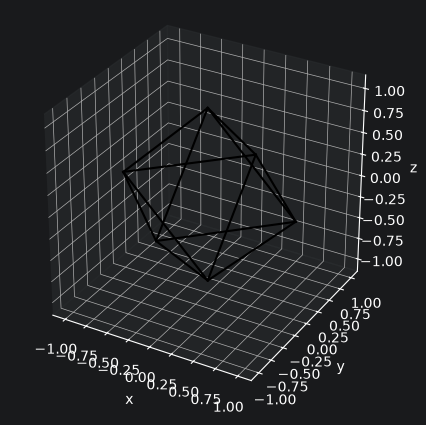

Количество ребер: 12


In [29]:
# Упражнение 3.27 — мини-проект
top, bottom = (0, 0, 1), (0, 0, -1)
xy_plane = [(1, 0, 0), (0, 1, 0), (-1, 0, 0), (0, -1, 0)]

edges = [(top, p) for p in xy_plane] + [(bottom, p) for p in xy_plane] + \
        [(xy_plane[i], xy_plane[(i + 1) % 4]) for i in range(4)]

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(projection="3d")
for start, end in edges:
    ax.plot(*zip(start, end), color="black")
set_equal_3d_axes(ax, [top, bottom] + xy_plane)
plt.show()
print(f"Количество ребер: {len(edges)}")

### Упражнение 3.28
**Идея решения:** Нормаль вычисляется векторным произведением двух смежных ребер грани. Циклическая перестановка трех вершин не меняет направление обхода треугольника (против часовой стрелки при взгляде снаружи), поэтому направление нормали сохраняется.
**Проверка:** Нормали для $[(1, 0, 0), (0, 1, 0), (0, 0, 1)]$ и циклической перестановки $[(0, 1, 0), (0, 0, 1), (1, 0, 0)]$ идентичны.

In [30]:
# Упражнение 3.28
def normal(face):
    return cross(subtract(face[1], face[0]), subtract(face[2], face[0]))

f1 = [(1, 0, 0), (0, 1, 0), (0, 0, 1)]
f2 = [(0, 1, 0), (0, 0, 1), (1, 0, 0)]

print(f"Нормаль 1: {normal(f1)}")
print(f"Нормаль 2: {normal(f2)}")

Нормаль 1: (1, 1, 1)
Нормаль 2: (1, 1, 1)
